In [1]:
# 결함사전이상탐지모델

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, auc, roc_curve
import joblib                                        # 파이썬 객체 저장을 위한 joblib
import tensorflow as tf                              # 텐서플로우 Lib
from tensorflow.keras import layers, models

np.random.seed(42)
tf.random.set_seed(42)

In [2]:
# 가상 센서 데이터 생성
n_normal = 5000   # 정상데이터 샘플 수
n_anomaly = 500   # 이상 데이터 샘플 수
n_features = 4    # 센서 개수

# 정상 데이터 : 평균 0, 표준편차 1인 정규분포 내에서 값을 생성
normal_data = np.random.normal(loc=0.0, scale=1.0, size=(n_normal, n_features))

# 이상 데이터 : 평균을 크게 이동시키고, 분산을 키워서 비정상적인 패턴의 센서 데이터 생성
anomal_data = np.random.normal(loc=3.0, scale=1.5, size=(n_anomaly, n_features))

# 정상과 이상 데이터를 위 아래로 이어 붙임
X = np.vstack([normal_data, anomal_data])

# 정상은 0, 이상은 1로 레이블 벡터 생성
y = np.hstack([np.zeros(n_normal), np.ones(n_anomaly)])

In [4]:
normal_data

array([[ 0.49671415, -0.1382643 ,  0.64768854,  1.52302986],
       [-0.23415337, -0.23413696,  1.57921282,  0.76743473],
       [-0.46947439,  0.54256004, -0.46341769, -0.46572975],
       ...,
       [ 2.03658236, -0.41274409,  1.23286679, -0.46866051],
       [ 0.88883882,  0.90249166,  0.95259051,  0.38782734],
       [ 1.37736658,  0.37835397,  1.71352973, -1.6199198 ]],
      shape=(5000, 4))

In [5]:
# 학습/테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# autoencoder는 정상 데이터로만 학습하므로 정상 샘플만 필터링
X_train_normal = X_train[y_train == 0]

In [6]:
# 데이터 스케일링
scaler = StandardScaler()
scaler.fit(X_train_normal)

X_train_normal_scaled = scaler.transform(X_train_normal)
X_test_scaled = scaler.transform(X_test)

In [8]:
# 모델 구조 정의
input_dim = n_features   # 입력 차원은 센서 개수와 동일하게 설정
encoding_dim = 2         # 잠재공간(Latent space) 2차원으로 설정해서 압축 진행

# 입력 레이어 정의 (입력 크기는 센서 크기와 동일해야함)
input_layer = layers.Input(shape=(input_dim,), name='input')


# 인코더 부분 (입력을 작은 차원으로 압축하는 레이어)
# 8개의 뉴런으로 첫번째 레이어를 구성
encoded = layers.Dense(8, activation='relu', name='encoder_dense1')(input_layer)
# 2차원 잠재 표현으로 압축
encoded = layers.Dense(encoding_dim, activation='relu', name='encoder_dense2')(encoded)

# 디코더 부분 (암축된 표현을 다시 원래 차원으로 복원하는 레이어)
# 8개의 뉴런으로 복원을 하는 중간 레이어
decoded = layers.Dense(8, activation='relu', name='decoder_dense1')(encoded)
# 원래 입력 차원으로 복원 출력
decoded = layers.Dense(input_dim, activation='linear', name='decoder_output')(decoded)


# 입력부터 출력까지를 연결해주는 autoencoder 모델 구성
autoencoder = models.Model(inputs=input_layer, outputs=decoded, name='autoencoder_model1')

autoencoder.summary()

Model: "autoencoder_model1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)                   │ (None, 4)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ encoder_dense1 (Dense)               │ (None, 8)                   │              40 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ encoder_dense2 (Dense)               │ (None, 2)                   │              18 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ decoder_dense1 (Dense)               │ (None, 8)                   │              24 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ decoder_output (Dense)               │ (None, 4)                   │              36 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 118 (472.00 B)

 Trainable params: 118 (472.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
# 모델 설정 및 컴파일
autoencoder.compile(optimizer='adam', loss='mse') # 입력과 복원된 출력의 차이를 제곱 오차로 계산, 학습 최적화는 adam 알고리즘 사용

# 모델 학습
history = autoencoder.fit(
    X_train_normal_scaled, # 입력과 타겟이 동일한 정상 데이터 사용
    X_train_normal_scaled, # 입력을 그대로 복원하도록 학습
    epochs=70,
    batch_size=64,
    validation_split=0.2,
    verbose=1 # 로그 출력
)

Epoch 1/70
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.0107 - val_loss: 0.9812
Epoch 2/70
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9433 - val_loss: 0.9222
Epoch 3/70
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8861 - val_loss: 0.8620
Epoch 4/70
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8257 - val_loss: 0.8017
Epoch 5/70
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7624 - val_loss: 0.7376
Epoch 6/70
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6948 - val_loss: 0.6760
Epoch 7/70
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6398 - val_loss: 0.6386
Epoch 8/70
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6078 - val_loss: 0.6184
Epoch 9/70
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5875 - val_loss: 0.6039
Epoch 10/70
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5722 - val_loss: 0.5926
Epoch 11/70
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5603 - val_loss: 0.5837
Epoch 12/70
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5510 - val_lo

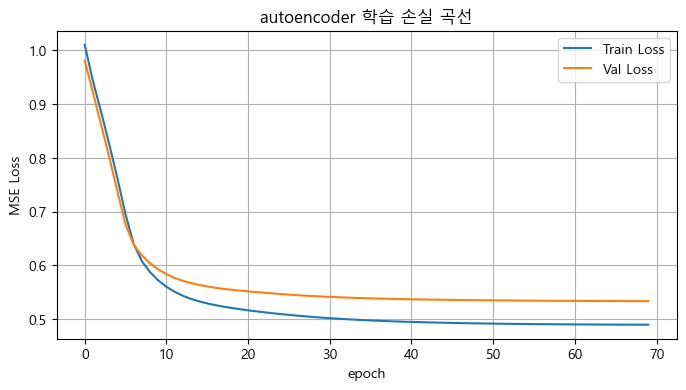

In [12]:
# 학습 결과 시각화
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("autoencoder 학습 손실 곡선")
plt.xlabel('epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# 테스트 데이터에서 재구성 오차 계산

# 테스트 데이터를 autoencoder 에 통과시켜서 복원값을 얻어옴
X_test_pred = autoencoder.predict(X_test_scaled)

# 각 샘플에 대해서(입력 - 복원값)^2 을 계산, 특징 차원방향으로 평균을 내서 재구성 오차를 구하는 공식
reconstruction_error = np.mean(np.square(X_test_scaled - X_test_pred), axis=1)

52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [14]:
# 이상 탐지 임계값 설정(threshold)

# 정상 학습 데이터의 재구성 오차 분포를 기반으로 임계값 설정
X_train_pred = autoencoder.predict(X_train_normal_scaled)  # 학습용 정상 데이터에서 복원값 구함
train_reconstruction_error = np.mean(                     # 정상 학습 데이터의 재구성 오차 계산
    np.square(X_train_normal_scaled - X_train_pred), axis=1
)

threshold = np.percentile(train_reconstruction_error, 95)  # 임계값 설정
print('이상탐지 임계값(95%) : ', threshold)

110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 935us/step
이상탐지 임계값(95%) :  1.4727892413958636


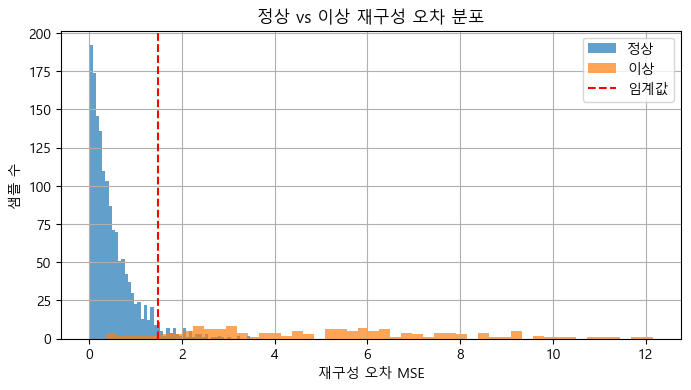

In [15]:
# 결과 시각화

plt.figure(figsize=(8,4))
plt.hist(reconstruction_error[y_test == 0], bins=50, alpha=0.7, label='정상')   # 정상 샘플 오차
plt.hist(reconstruction_error[y_test == 1], bins=50, alpha=0.7, label='이상')   # 이상 샘플 오차
plt.axvline(threshold, color='red', linestyle='--', label='임계값')

plt.title("정상 vs 이상 재구성 오차 분포")
plt.xlabel("재구성 오차 MSE")
plt.ylabel("샘플 수")
plt.legend()
plt.grid(True)
plt.show()